# Fake News Detection with NLP

This notebook trains a classifier that labels news articles as **real** or **fake**.

**Pipeline:** Kaggle dataset + web-scraped articles → text cleaning → TF-IDF → Logistic Regression and Multinomial Naive Bayes → evaluation on a held-out test set.

It also checks whether the classifier relies on *source markers* (for example the "Reuters" dateline that almost every real article in the dataset starts with) instead of the content, and adds three small tools: summarization, sentiment analysis and a keyword search engine.

**Contents**
1. Setup
2. Load the Kaggle dataset
3. Scrape additional articles
4. Combine, deduplicate and clean
5. Exploratory analysis
6. Train / validation / test split
7. Experiment A: models on the cleaned text
8. Experiment B: models without source markers
9. Final evaluation on the test set
10. Summarization and sentiment analysis
11. Keyword search engine

## 1. Setup

In [8]:
import os
import time
from pathlib import Path
from urllib.parse import urljoin, urlparse

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, classification_report,
                             f1_score, precision_score, recall_score)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from wordcloud import WordCloud

from text_utils import clean_text, remove_source_markers

# ---- Settings ----
RANDOM_STATE = 42
RUN_SCRAPER = True                      # False = use only the Kaggle data (fully reproducible)
SCRAPED_CSV = Path("data/scraped_articles.csv")   # scraped articles are cached here
DATA_DIR = os.environ.get("FAKE_NEWS_DATA_DIR")   # optional: folder with Fake.csv and True.csv
RUN_TRANSFORMERS = True                 # summarization + sentiment (downloads ~1.5 GB of models)

IMG_DIR = Path("images"); IMG_DIR.mkdir(exist_ok=True)
MODEL_DIR = Path("models"); MODEL_DIR.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")

## 2. Load the Kaggle dataset

[Fake and Real News Dataset](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset) (ISOT, University of Victoria): real articles from Reuters and fake articles from sites flagged by PolitiFact and Wikipedia, mostly from 2016–2017. It is downloaded with `kagglehub`. If you downloaded the CSV files yourself, set the environment variable `FAKE_NEWS_DATA_DIR` to their folder.

Labels: **0 = real**, **1 = fake**.

In [10]:
if DATA_DIR is None:
    import kagglehub
    DATA_DIR = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")

df_fake = pd.read_csv(Path(DATA_DIR) / "Fake.csv").assign(label=1, source="kaggle")
df_real = pd.read_csv(Path(DATA_DIR) / "True.csv").assign(label=0, source="kaggle")
df_kaggle = pd.concat([df_real, df_fake], ignore_index=True)[["title", "text", "label", "source"]]
df_kaggle["url"] = ""
print(f"Kaggle: {len(df_real)} real, {len(df_fake)} fake")

Kaggle: 21417 real, 23481 fake


## 3. Scrape additional articles

To add more recent and more varied examples, the scraper collects up to 50 articles per site from the front pages of real news sites and of satire / fake news sites. Only pages with more than 100 words of paragraph text are kept, and it waits one second between requests. Results are cached in `data/scraped_articles.csv`, so the sites are only visited once.

Note that some of the "fake" sites (for example The Onion) publish **satire**, which is labelled fake here because it is not true, even though it is not meant to deceive.

In [12]:
HEADERS = {"User-Agent": "Mozilla/5.0 (fake-news-detection student project)"}

REAL_SOURCES = ["https://www.bbc.com/news", "https://www.reuters.com", "https://www.npr.org/sections/news"]
FAKE_SOURCES = ["https://www.theonion.com", "https://worldnewsdailyreport.com", "https://newspunch.com",
                "https://empirenews.net", "https://www.huzlers.com"]


def extract_article_text(url):
    # Return the text of all <p> tags on a page ("" if the request fails).
    try:
        res = requests.get(url, headers=HEADERS, timeout=10)
        res.raise_for_status()
    except requests.RequestException:
        return ""
    soup = BeautifulSoup(res.content, "html.parser")
    return " ".join(p.get_text(" ", strip=True) for p in soup.find_all("p"))


def scrape_site(base_url, label, limit=50, min_words=100, delay=1.0):
    # Follow links on a site's front page and keep pages that look like articles.
    domain = urlparse(base_url).netloc.removeprefix("www.")
    try:
        res = requests.get(base_url, headers=HEADERS, timeout=10)
        res.raise_for_status()
    except requests.RequestException as err:
        print(f"  skipped {base_url}: {err}")
        return []

    soup = BeautifulSoup(res.content, "html.parser")
    seen, articles = set(), []
    for a in soup.find_all("a", href=True):
        url = urljoin(base_url, a["href"]).split("#")[0]
        if not urlparse(url).netloc.endswith(domain) or url in seen:
            continue                      # other site, or already visited
        seen.add(url)
        title = a.get_text(strip=True)
        text = extract_article_text(url)
        time.sleep(delay)                 # be polite to the server
        if title and len(text.split()) > min_words:
            articles.append({"title": title, "text": text, "label": label,
                             "source": domain, "url": url})
        if len(articles) >= limit:
            break
    print(f"  {domain}: {len(articles)} articles")
    return articles


if SCRAPED_CSV.exists():
    df_web = pd.read_csv(SCRAPED_CSV).fillna({"url": ""})
    print(f"Loaded {len(df_web)} cached scraped articles from {SCRAPED_CSV}")
elif RUN_SCRAPER:
    rows = []
    for site in REAL_SOURCES:
        rows += scrape_site(site, label=0)
    for site in FAKE_SOURCES:
        rows += scrape_site(site, label=1)
    df_web = pd.DataFrame(rows, columns=["title", "text", "label", "source", "url"])
    SCRAPED_CSV.parent.mkdir(exist_ok=True)
    df_web.to_csv(SCRAPED_CSV, index=False)
else:
    df_web = pd.DataFrame(columns=["title", "text", "label", "source", "url"])

counts = df_web["label"].value_counts().reindex([0, 1], fill_value=0)
print(f"Scraped articles: {counts[0]} real, {counts[1]} fake")

Loaded 192 cached scraped articles from data\scraped_articles.csv
Scraped articles: 100 real, 92 fake


## 4. Combine, deduplicate and clean

Two problems in the raw data are fixed before anything else:

* **Empty articles.** Several hundred fake articles have no text (only a title or a video).
* **Duplicates.** Some articles appear more than once. If one copy lands in the training set and another in the test set, the test score is too optimistic, so duplicates are removed *before* splitting.

Cleaning (`text_utils.clean_text`): remove URLs, keep letters only, lowercase, remove stopwords and lemmatize. The same function is used by the chatbot, so new text is cleaned exactly like the training data.

In [14]:
df = pd.concat([df_kaggle, df_web], ignore_index=True)
df["text"] = df["text"].fillna("").astype(str).str.strip()
df["title"] = df["title"].fillna("").astype(str)
df["label"] = df["label"].astype(int)
n_start = len(df)

df = df[df["text"].str.split().str.len() >= 20]                       # drop empty / very short texts
n_short = n_start - len(df)
df = df.drop_duplicates(subset="text").reset_index(drop=True)          # drop exact duplicates
n_dup = n_start - n_short - len(df)

df["clean"] = df["text"].apply(clean_text)                             # Experiment A input
df["clean_no_markers"] = df["text"].apply(lambda t: clean_text(remove_source_markers(t)))  # Experiment B input

print(f"Removed {n_short} empty/short and {n_dup} duplicate articles")
print(f"Final dataset: {len(df)} articles "
      f"({(df.label == 0).sum()} real, {(df.label == 1).sum()} fake)")
df[["title", "clean", "label"]].head()

Removed 1131 empty/short and 5498 duplicate articles
Final dataset: 38461 articles (21288 real, 17173 fake)


,title,clean,label
0,"As U.S. budget fight looms, Republicans flip t...",washington reuters head conservative republica...,0
1,U.S. military to accept transgender recruits o...,washington reuters transgender people allowed ...,0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,washington reuters special counsel investigati...,0
3,FBI Russia probe helped by Australian diplomat...,washington reuters trump campaign adviser geor...,0
4,Trump wants Postal Service to charge 'much mor...,seattle washington reuters president donald tr...,0


## 5. Exploratory analysis

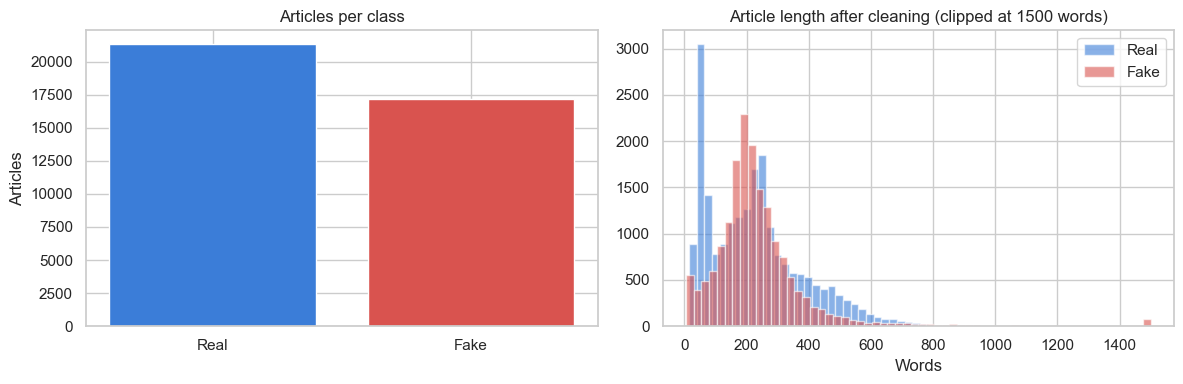

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df["label"].map({0: "Real", 1: "Fake"}).value_counts().reindex(["Real", "Fake"])
axes[0].bar(counts.index, counts.values, color=["#3b7dd8", "#d9534f"])
axes[0].set_title("Articles per class")
axes[0].set_ylabel("Articles")

lengths = df["clean"].str.split().str.len()
for label, name, color in [(0, "Real", "#3b7dd8"), (1, "Fake", "#d9534f")]:
    axes[1].hist(lengths[df.label == label].clip(upper=1500), bins=60, alpha=0.6, label=name, color=color)
axes[1].set_title("Article length after cleaning (clipped at 1500 words)")
axes[1].set_xlabel("Words")
axes[1].legend()
plt.tight_layout()
plt.savefig(IMG_DIR / "class_balance_and_length.png", dpi=120, bbox_inches="tight")
plt.show()

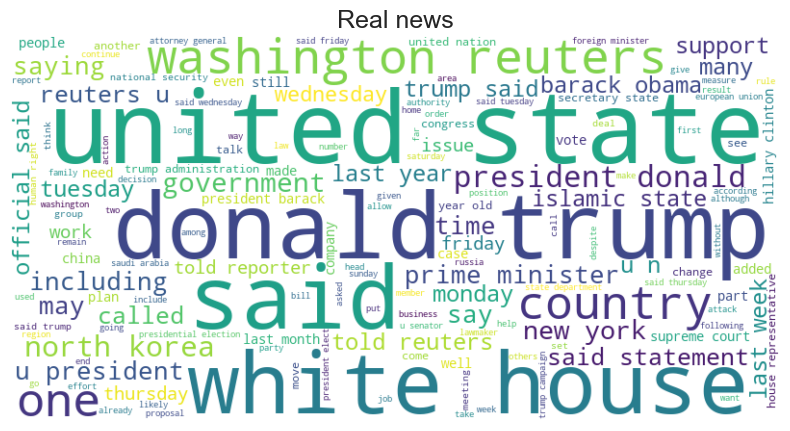

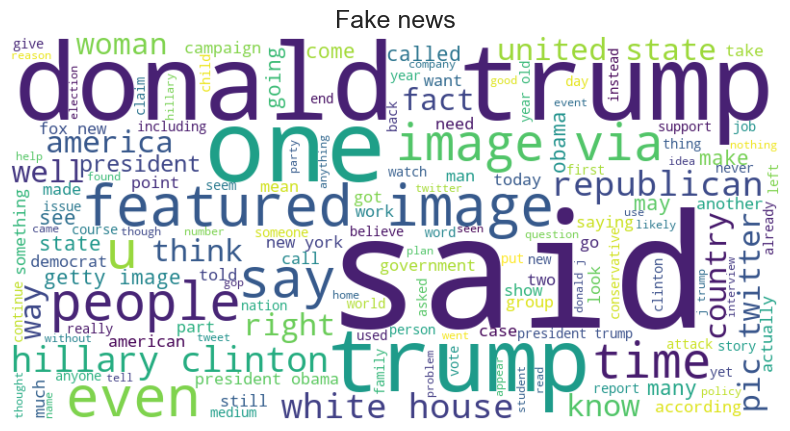

In [17]:
def plot_wordcloud(text, title, path):
    wc = WordCloud(width=800, height=400, background_color="white", random_state=RANDOM_STATE,
                   max_words=150).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=18)
    plt.savefig(path, dpi=100, bbox_inches="tight")
    plt.show()


plot_wordcloud(" ".join(df.loc[df.label == 0, "clean"]), "Real news", IMG_DIR / "wordcloud_real.png")
plot_wordcloud(" ".join(df.loc[df.label == 1, "clean"]), "Fake news", IMG_DIR / "wordcloud_fake.png")

"washington reuters" is one of the most frequent phrases in the real-news word cloud. It comes from the dateline at the start of the Reuters articles, not from what the articles say. This is checked in Experiment B.

## 6. Train / validation / test split

Stratified split into **70% training, 15% validation and 15% test**. Models are compared on the validation set; the test set is used only once, for the final model.

In [20]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=RANDOM_STATE)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=RANDOM_STATE)
y_train, y_val, y_test = train_df["label"], val_df["label"], test_df["label"]
print(f"Train: {len(train_df)}  Validation: {len(val_df)}  Test: {len(test_df)}")

Train: 26922  Validation: 5769  Test: 5770


## 7. Experiment A: models on the cleaned text

Both models use TF-IDF features (top 5000 words). The vectorizer is inside a scikit-learn `Pipeline`, so it is fitted on the training set only.

In [22]:
def make_models():
    tfidf = dict(max_features=5000, stop_words="english")
    return {
        "Logistic Regression": Pipeline([("tfidf", TfidfVectorizer(**tfidf)),
                                         ("clf", LogisticRegression(max_iter=1000))]),
        "Multinomial Naive Bayes": Pipeline([("tfidf", TfidfVectorizer(**tfidf)),
                                             ("clf", MultinomialNB())]),
    }


def scores(y_true, y_pred):
    return {"Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred),
            "Recall": recall_score(y_true, y_pred),
            "F1": f1_score(y_true, y_pred)}


def run_experiment(text_col):
    # Train both models on train_df[text_col] and score them on the validation set.
    fitted, rows = {}, {}
    for name, pipe in make_models().items():
        pipe.fit(train_df[text_col], y_train)
        fitted[name] = pipe
        rows[name] = scores(y_val, pipe.predict(val_df[text_col]))
    return fitted, pd.DataFrame(rows).T


models_a, val_a = run_experiment("clean")
print("Validation scores (precision/recall/F1 for the 'fake' class):")
val_a.round(4)

Validation scores (precision/recall/F1 for the 'fake' class):


,Accuracy,Precision,Recall,F1
Logistic Regression,0.9802,0.9831,0.9724,0.9778
Multinomial Naive Bayes,0.9269,0.9133,0.9239,0.9186


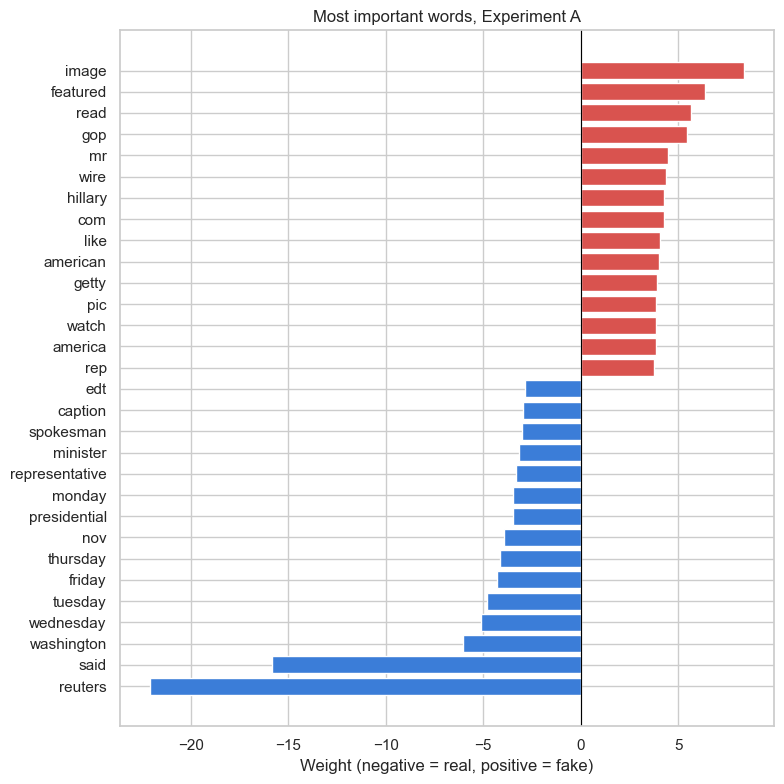

In [23]:
def plot_top_features(pipe, title, path, n=15):
    # Words with the largest Logistic Regression weights towards each class.
    words = pipe.named_steps["tfidf"].get_feature_names_out()
    coef = pipe.named_steps["clf"].coef_[0]          # positive = fake, negative = real
    order = np.argsort(coef)
    top = np.r_[order[:n], order[-n:]]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.barh(words[top], coef[top], color=["#3b7dd8"] * n + ["#d9534f"] * n)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Weight (negative = real, positive = fake)")
    plt.tight_layout()
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()


plot_top_features(models_a["Logistic Regression"], "Most important words, Experiment A",
                  IMG_DIR / "top_features_A.png")

## 8. Experiment B: models without source markers

A very high score can mean the model has learned *where* an article comes from instead of *what* it says. In this dataset, almost every real article starts with a dateline such as "WASHINGTON (Reuters) -", and many fake articles end with image credits ("Featured image via ...").

Here the same models are trained after `text_utils.remove_source_markers` removes these markers. If the score drops a lot, Experiment A was partly measuring the source, not the content.

In [25]:
models_b, val_b = run_experiment("clean_no_markers")

comparison = pd.concat({"A: cleaned text": val_a, "B: source markers removed": val_b}).round(4)
comparison

Accuracy  Precision  \
A: cleaned text           Logistic Regression        0.9802     0.9831   
                          Multinomial Naive Bayes    0.9269     0.9133   
B: source markers removed Logistic Regression        0.9691     0.9724   
                          Multinomial Naive Bayes    0.9149     0.8965   

                                                   Recall      F1  
A: cleaned text           Logistic Regression      0.9724  0.9778  
                          Multinomial Naive Bayes  0.9239  0.9186  
B: source markers removed Logistic Regression      0.9581  0.9652  
                          Multinomial Naive Bayes  0.9150  0.9057

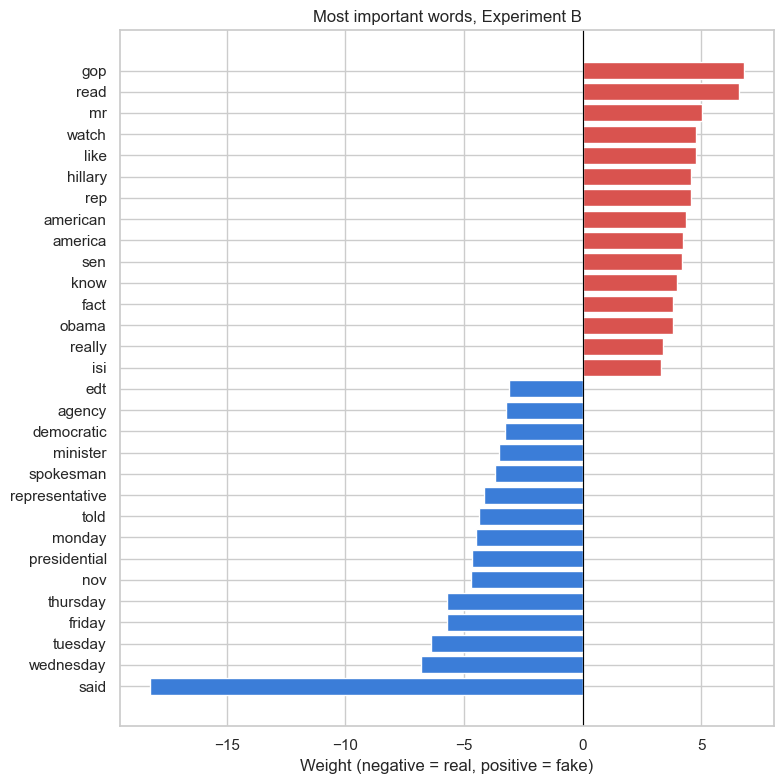

In [26]:
plot_top_features(models_b["Logistic Regression"], "Most important words, Experiment B",
                  IMG_DIR / "top_features_B.png")

## 9. Final evaluation on the test set

The final model is the one from Experiment B with the best validation F1, because it does not depend on the Reuters dateline and should transfer better to articles from other sources. It is evaluated once on the test set, and the Experiment A model is shown for comparison.

In [28]:
best_name = val_b["F1"].idxmax()
final_model = models_b[best_name]
print(f"Final model: {best_name} (Experiment B)\n")

y_pred = final_model.predict(test_df["clean_no_markers"])
print(classification_report(y_test, y_pred, target_names=["Real", "Fake"], digits=4))

test_results = pd.DataFrame({
    f"A: {best_name}": scores(y_test, models_a[best_name].predict(test_df["clean"])),
    f"B: {best_name} (final)": scores(y_test, y_pred),
}).T.round(4)
test_results

Final model: Logistic Regression (Experiment B)

              precision    recall  f1-score   support

        Real     0.9681    0.9790    0.9735      3194
        Fake     0.9736    0.9600    0.9668      2576

    accuracy                         0.9705      5770
   macro avg     0.9709    0.9695    0.9702      5770
weighted avg     0.9706    0.9705    0.9705      5770



,Accuracy,Precision,Recall,F1
A: Logistic Regression,0.9825,0.9836,0.9771,0.9803
B: Logistic Regression (final),0.9705,0.9736,0.9600,0.9668


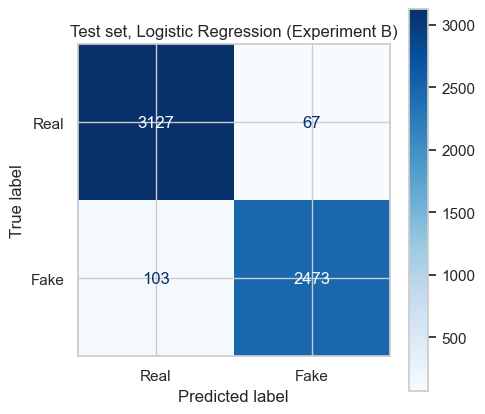

In [29]:
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Real", "Fake"],
                                        cmap="Blues", values_format="d", ax=ax)
ax.set_title(f"Test set, {best_name} (Experiment B)")
plt.tight_layout()
plt.savefig(IMG_DIR / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

In [30]:
# Per-source accuracy on the test set: shows whether the scraped articles are harder
by_source = (test_df.assign(correct=(y_pred == y_test.values))
             .assign(group=lambda d: np.where(d["source"] == "kaggle", "Kaggle", "Scraped"))
             .groupby("group")["correct"].agg(["count", "mean"])
             .rename(columns={"count": "articles", "mean": "accuracy"}))
by_source.round(4)

,articles,accuracy
group,,
Kaggle,5741,0.9720
Scraped,29,0.6897


In [31]:
# Save the final pipeline (TF-IDF + classifier) for chatbot.py
joblib.dump(final_model, MODEL_DIR / "fake_news_pipeline.joblib")
print("Saved", MODEL_DIR / "fake_news_pipeline.joblib")

Saved models\fake_news_pipeline.joblib


## 10. Summarization and sentiment analysis

Two pre-trained Hugging Face models give extra context for an article:

* **Summarization:** `sshleifer/distilbart-cnn-12-6`, a smaller BART model fine-tuned on CNN/DailyMail news.
* **Sentiment:** `distilbert-base-uncased-finetuned-sst-2-english`.

Both work on the **original** text, because removing stopwords makes text unreadable for these models.

In [33]:
sample_text = test_df["text"].iloc[0]
print(sample_text[:500], "...\n")

if RUN_TRANSFORMERS:
    import warnings
    import torch
    from transformers import (AutoModelForSeq2SeqLM, AutoModelForSequenceClassification,
                              AutoTokenizer, logging)

    os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"    # harmless Windows cache warning
    warnings.filterwarnings("ignore")
    logging.set_verbosity_error()

    # Summarization: load DistilBART directly (the "summarization" pipeline was removed in transformers v5)
    SUM_MODEL = "sshleifer/distilbart-cnn-12-6"
    sum_tokenizer = AutoTokenizer.from_pretrained(SUM_MODEL)
    sum_model = AutoModelForSeq2SeqLM.from_pretrained(SUM_MODEL)

    def summarize(text, max_length=100, min_length=30):
        inputs = sum_tokenizer(text, return_tensors="pt", truncation=True, max_length=1024)
        with torch.no_grad():
            ids = sum_model.generate(**inputs, max_length=max_length, min_length=min_length,
                                     num_beams=4, early_stopping=True)
        return sum_tokenizer.decode(ids[0], skip_special_tokens=True).strip()

    # Sentiment: DistilBERT fine-tuned on SST-2
    SENT_MODEL = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
    sent_tokenizer = AutoTokenizer.from_pretrained(SENT_MODEL)
    sent_model = AutoModelForSequenceClassification.from_pretrained(SENT_MODEL)

    def analyze_sentiment(text):
        inputs = sent_tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
        with torch.no_grad():
            probs = sent_model(**inputs).logits.softmax(dim=-1)[0]
        best = int(probs.argmax())
        return sent_model.config.id2label[best].lower(), float(probs[best])

    print("Summary:", summarize(sample_text))
    label, score = analyze_sentiment(sample_text)
    print(f"Sentiment: {label} ({score:.2f})")

WASHINGTON (Reuters) - U.S. President-elect Donald Trump has announced the two top White House advisers but still has many key administration positions to fill ahead of his inauguration on Jan. 20. Trump announced on Sunday he will hire Republican National Committee Chairman Reince Priebus as White House chief of staff and named Stephen Bannon, former head of the conservative website Breitbart News, as his chief strategist and senior counselor. Below are people mentioned as contenders for senior ...



Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Summary: Donald Trump has announced the two top White House advisers but still has many key administration positions to fill . Trump announced on Sunday he will hire Reince Priebus as White House chief of staff . Stephen Bannon, former head of the conservative website Breitbart News, will be his chief strategist and senior counselor . Trump still has a number of people mentioned as contenders for senior roles .
Sentiment: positive (0.82)


## 11. Keyword search engine

A small search engine over the dataset: documents and query are turned into TF-IDF vectors, and articles are ranked by cosine similarity.

In [35]:
class SimpleSearchEngine:
    def __init__(self, docs, titles, labels):
        self.vectorizer = TfidfVectorizer(stop_words="english", max_features=20000)
        self.doc_vectors = self.vectorizer.fit_transform(docs)
        self.titles = list(titles)
        self.labels = list(labels)

    def search(self, query, top_k=5):
        query_vec = self.vectorizer.transform([clean_text(query)])
        sims = cosine_similarity(query_vec, self.doc_vectors).ravel()
        best = np.argsort(sims)[::-1][:top_k]
        return pd.DataFrame({"title": [self.titles[i] for i in best],
                             "label": ["fake" if self.labels[i] else "real" for i in best],
                             "score": sims[best].round(3)})


search_engine = SimpleSearchEngine(df["clean"], df["title"], df["label"])
search_engine.search("tax reform budget vote")

,title,label,score
0,Democrat sees bipartisan support for corporate...,real,0.576
1,'Big Six' member says tax reform blueprint to ...,real,0.553
2,House budget chief expects budget resolution a...,real,0.540
3,"Senate passes budget blueprint, key to Trump t...",real,0.531
4,Trump tax cut plan gains momentum after U.S. b...,real,0.519


## Interactive chatbot

The interactive version is in `chatbot.py`. It loads `models/fake_news_pipeline.joblib` and prints the prediction, a summary and the sentiment for any pasted article:

```bash
python chatbot.py
```